# Group 02 — Part B — Bonus Notebook: Label-Efficiency Ablation

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

## What this notebook does

**Grid:** 5 label fractions (10/20/30/40/50%) x 2 initializations (best SSL backbone = SimCLR,
supervised baseline = COCO-pretrained) = 10 cells in the grid. The two 20% cells are **reused**
from Task 1 (Notebook 1b's SimCLR@20% result and its COCO-pretrained@20% baseline) rather than
retrained, so this notebook actually runs **8 new fine-tuning jobs**, 50 epochs each for this ablation -- deliberately shorter than Task 1's 150-epoch protocol.

**Nesting strategy:** D0.1 subset subset D0.2 subset D0.3 subset D0.4 subset D0.5, built around the *existing*
Task-1 20% subset rather than resampling from scratch:
- D0.1 = a stratified half of the existing D0.2 (so D0.1 subset D0.2)
- D0.2 = reused exactly as Task 1 built it
- D0.3 / D0.4 / D0.5 = D0.2 plus additional stratified images pulled from the remaining 80%
  SSL pool, each step adding ~10% of the pool (so D0.2 subset D0.3 subset D0.4 subset D0.5)

Copy-paste augmentation (60% of majority-class instance count) is reapplied independently to
every new fraction's own training subset -- never to val/test.

## 1. Install dependencies

In [1]:
%%capture
%pip install -q --upgrade ultralytics lapx
%pip install -q --upgrade "git+https://github.com/rifat963/ssl-detection-lab.git@main"

## 2. Imports

In [2]:
import json
import random
import shutil
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from packaging.version import Version
from ultralytics import YOLO
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import ssldet
from ssldet import EvaluationConfig, evaluate, transfer_ssl_backbone_to_yolo

assert torch.cuda.is_available(), "Select a Kaggle GPU before running the ablation."
assert Version(ssldet.__version__) >= Version("0.8.1"), ssldet.__version__
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("ssl-detection-lab:", ssldet.__version__)
print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab: 0.9.0
GPU: Tesla T4


## 3. Config

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")
WORK_DIR.mkdir(parents=True, exist_ok=True)

LABEL_FRACTIONS = [0.10, 0.20, 0.30, 0.40, 0.50]
INITS = ["simclr", "coco"]
EPOCHS_BONUS = 50            # PDF standard budget for this ablation -- NOT Task 1's 150
IMAGE_SIZE = 640
BATCH_SIZE = 32
PATIENCE = 15
CLOSE_MOSAIC = 30
MODEL_NAME = "yolo26n"
YOLO_YAML = "yolo26n.yaml"

TARGET_RATIO = 0.60          # copy-paste target: 60% of majority-class instance count
PART_A_MAP5095 = 0.460       # Part A 100%-label reference -- update if yours differs

OUTPUT_DIR = WORK_DIR / "bonus_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

ABLATION_SUFFIXES = ["_temp010", "_control", "_momentum099"]  # exclude exercise checkpoints

print("Config loaded.")


Config loaded.


---
## Part 0 — Load partition manifest + SimCLR checkpoint + rebuild data.yaml


In [4]:
_manifest_hits = sorted(INPUT_ROOT.rglob("partition_manifest.json"))
if not _manifest_hits:
    raise FileNotFoundError(
        "No partition_manifest.json found under /kaggle/input. "
        "Attach group02-dataset-eda's output as an input to this notebook."
    )
partition_manifest = json.loads(_manifest_hits[0].read_text())
BASE_DIR = _manifest_hits[0].parent

CLASS_NAMES = partition_manifest["class_names"]
MANIFEST_SEED = partition_manifest["seed"]
STEMS_POOL = partition_manifest["stems_ssl_pool_raw"]          # 80% SSL pool, raw stems
STEMS_D02 = partition_manifest["stems_labelled20_raw"]         # existing Task-1 20% subset

RESPLIT_ROOT = BASE_DIR / "dataset-resplit"
LABELLED20_ROOT = BASE_DIR / "dataset-labelled20"               # Task 1's ready-made D0.2 (augmented)

print(f"SSL pool: {len(STEMS_POOL)} images | existing D0.2: {len(STEMS_D02)} images | seed: {MANIFEST_SEED}")


SSL pool: 1339 images | existing D0.2: 267 images | seed: 42


In [5]:
def find_ssl_checkpoint(method):
    hits = [p for p in INPUT_ROOT.rglob(f"*_ssl.pt")
            if not any(suffix in str(p) for suffix in ABLATION_SUFFIXES)]
    if not hits:
        raise FileNotFoundError(f"No SSL checkpoint found under /kaggle/input for {method}.")
    return hits[0]

SSL_CHECKPOINT = find_ssl_checkpoint("simclr")
print("SimCLR SSL checkpoint:", SSL_CHECKPOINT)


SimCLR SSL checkpoint: /kaggle/input/notebooks/arifulislamopi/group02-partb-1a-simclr-pretrain/simclr_kiitmita/last_ssl.pt


In [6]:
# SSL-pool images/labels live under BASE_DIR's raw pool tree -- reuse the same resolver
# Task 1 used (RESPLIT_ROOT/train) for the raw pool source, same convention here.
POOL_IMAGES_DIR = RESPLIT_ROOT / "train" / "images"
POOL_LABELS_DIR = RESPLIT_ROOT / "train" / "labels"
if not POOL_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Expected SSL pool images at {POOL_IMAGES_DIR}")

print("Pool images dir:", POOL_IMAGES_DIR)


Pool images dir: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images


---
## Part 1 — Build nested label-fraction subsets (D0.1 subset D0.2 subset D0.3 subset D0.4 subset D0.5)


In [7]:
def dominant_class_for_stem(stem):
    # majority class id present in this image's YOLO label file -- used only for
    # stratified sampling, not for training itself
    label_path = POOL_LABELS_DIR / f"{stem}.txt"
    if not label_path.exists():
        return -1
    class_ids = [int(line.split()[0]) for line in label_path.read_text().splitlines() if line.strip()]
    if not class_ids:
        return -1
    return max(set(class_ids), key=class_ids.count)

dominant_by_stem = {s: dominant_class_for_stem(s) for s in tqdm(STEMS_POOL, desc="Reading labels for stratification")}


Reading labels for stratification:   0%|          | 0/1339 [00:00<?, ?it/s]

In [8]:
# D0.1 -- stratified half of the existing D0.2 (guarantees D0.1 subset D0.2)
dominant_d02 = [dominant_by_stem[s] for s in STEMS_D02]
stems_d01, _ = train_test_split(STEMS_D02, train_size=0.5, random_state=SEED, stratify=dominant_d02)

# D0.3 / D0.4 / D0.5 -- grow D0.2 by adding ~10%-of-pool stratified increments each step
remaining_pool = [s for s in STEMS_POOL if s not in set(STEMS_D02)]

def add_stratified_increment(current_stems, pool_candidates, n_to_add, seed):
    if n_to_add <= 0 or not pool_candidates:
        return current_stems, pool_candidates
    dominant_candidates = [dominant_by_stem[s] for s in pool_candidates]
    # guard against a stratify class with <2 members -- fall back to unstratified sampling
    from collections import Counter
    counts = Counter(dominant_candidates)
    stratify_arg = dominant_candidates if min(counts.values()) >= 2 else None
    n_to_add = min(n_to_add, len(pool_candidates))
    added, rest = train_test_split(pool_candidates, train_size=n_to_add, random_state=seed,
                                    stratify=stratify_arg)
    return current_stems + added, rest

increment = int(round(0.10 * len(STEMS_POOL)))

stems_d03, remaining_pool = add_stratified_increment(list(STEMS_D02), remaining_pool, increment, SEED + 3)
stems_d04, remaining_pool = add_stratified_increment(stems_d03, remaining_pool, increment, SEED + 4)
stems_d05, remaining_pool = add_stratified_increment(stems_d04, remaining_pool, increment, SEED + 5)

SUBSETS = {0.10: stems_d01, 0.20: STEMS_D02, 0.30: stems_d03, 0.40: stems_d04, 0.50: stems_d05}

for frac, stems in SUBSETS.items():
    print(f"D{frac:.1f}: {len(stems)} images")


D0.1: 133 images
D0.2: 267 images
D0.3: 401 images
D0.4: 535 images
D0.5: 669 images


In [9]:
# Verify strict nesting -- required for the report and Viva Q1
ordered = [0.10, 0.20, 0.30, 0.40, 0.50]
for a, b in zip(ordered, ordered[1:]):
    ok = set(SUBSETS[a]).issubset(set(SUBSETS[b]))
    print(f"D{a:.1f} subset D{b:.1f}: {'PASS' if ok else 'FAIL'}")
    assert ok, f"Nesting violated between D{a} and D{b}"


D0.1 subset D0.2: PASS
D0.2 subset D0.3: PASS
D0.3 subset D0.4: PASS
D0.4 subset D0.5: PASS


---
## Part 2 — Materialize each new subset + reapply copy-paste augmentation

D0.2 already exists (Task 1's `dataset-labelled20`, already copy-paste augmented) -- reused as-is.
D0.1/D0.3/D0.4/D0.5 are freshly copied from the raw pool, then copy-paste augmented independently
(target: 60% of that subset's own majority-class instance count).


In [10]:
def materialize_subset(frac, stems):
    root = OUTPUT_DIR / f"dataset_{int(frac*100):02d}pct"
    img_dir, lbl_dir = root / "train" / "images", root / "train" / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    for stem in stems:
        src_img = next(POOL_IMAGES_DIR.glob(f"{stem}.*"), None)
        src_lbl = POOL_LABELS_DIR / f"{stem}.txt"
        if src_img is None:
            continue
        shutil.copy2(src_img, img_dir / src_img.name)
        if src_lbl.exists():
            shutil.copy2(src_lbl, lbl_dir / src_lbl.name)
    return root

def read_boxes(lbl_dir, stems):
    rows = []
    for stem in stems:
        p = lbl_dir / f"{stem}.txt"
        if not p.exists():
            continue
        for line in p.read_text().splitlines():
            if not line.strip():
                continue
            cls, cx, cy, w, h = line.split()
            rows.append({"stem": stem, "class_id": int(cls), "cx": float(cx), "cy": float(cy),
                         "w": float(w), "h": float(h)})
    return pd.DataFrame(rows)

def copy_paste_augment(root, stems):
    img_dir, lbl_dir = root / "train" / "images", root / "train" / "labels"
    boxes = read_boxes(lbl_dir, stems)
    if boxes.empty:
        print(f"  {root.name}: no boxes found, skipping copy-paste")
        return
    boxes["class_name"] = boxes["class_id"].map(dict(enumerate(CLASS_NAMES)))
    counts = boxes["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    target = int(counts.max() * TARGET_RATIO)

    crops_by_class = {}
    for stem, grp in boxes.groupby("stem"):
        img_path = next(img_dir.glob(f"{stem}.*"), None)
        if img_path is None:
            continue
        img = np.array(Image.open(img_path).convert("RGB"))
        h, w = img.shape[:2]
        for _, row in grp.iterrows():
            x1 = max(0, int((row.cx - row.w / 2) * w)); y1 = max(0, int((row.cy - row.h / 2) * h))
            x2 = min(w, int((row.cx + row.w / 2) * w)); y2 = min(h, int((row.cy + row.h / 2) * h))
            if x2 - x1 < 4 or y2 - y1 < 4:
                continue
            crops_by_class.setdefault(row.class_name, []).append(img[y1:y2, x1:x2].copy())

    per_stem = boxes.groupby("stem").size()
    receivers = sorted(stems, key=lambda s: per_stem.get(s, 0))
    added = 0
    rng = random.Random(SEED)
    for class_name in CLASS_NAMES:
        deficit = target - counts[class_name]
        if deficit <= 0 or class_name not in crops_by_class:
            continue
        crops = crops_by_class[class_name]
        class_id = CLASS_NAMES.index(class_name)
        n_needed = int(deficit)
        for k in range(n_needed):
            receiver_stem = receivers[k % len(receivers)]
            img_path = next(img_dir.glob(f"{receiver_stem}.*"), None)
            if img_path is None:
                continue
            base = np.array(Image.open(img_path).convert("RGB"))
            H, W = base.shape[:2]
            crop = rng.choice(crops)
            ch, cw = crop.shape[:2]
            if ch >= H or cw >= W:
                continue
            x0 = rng.randint(0, W - cw); y0 = rng.randint(0, H - ch)
            base[y0:y0 + ch, x0:x0 + cw] = crop
            out_stem = f"cp_{class_name}_{added}_{receiver_stem}"
            Image.fromarray(base).save(img_dir / f"{out_stem}.jpg")
            cx, cy = (x0 + cw / 2) / W, (y0 + ch / 2) / H
            bw, bh = cw / W, ch / H
            existing = (lbl_dir / f"{receiver_stem}.txt").read_text() if (lbl_dir / f"{receiver_stem}.txt").exists() else ""
            (lbl_dir / f"{out_stem}.txt").write_text(existing + f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
            added += 1
    print(f"  {root.name}: copy-paste added {added} synthetic instances (target/class={target})")

subset_roots = {0.20: LABELLED20_ROOT}
for frac in [0.10, 0.30, 0.40, 0.50]:
    root = materialize_subset(frac, SUBSETS[frac])
    copy_paste_augment(root, SUBSETS[frac])
    subset_roots[frac] = root

for frac, root in sorted(subset_roots.items()):
    n = len(list((root / "train" / "images").glob("*")))
    print(f"D{frac:.1f} final train image count (post copy-paste): {n}  -> {root}")


  dataset_10pct: copy-paste added 80 synthetic instances (target/class=53)
  dataset_30pct: copy-paste added 233 synthetic instances (target/class=150)
  dataset_40pct: copy-paste added 298 synthetic instances (target/class=198)
  dataset_50pct: copy-paste added 447 synthetic instances (target/class=267)
D0.1 final train image count (post copy-paste): 213  -> /kaggle/working/bonus_outputs/dataset_10pct
D0.2 final train image count (post copy-paste): 453  -> /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-labelled20
D0.3 final train image count (post copy-paste): 634  -> /kaggle/working/bonus_outputs/dataset_30pct
D0.4 final train image count (post copy-paste): 833  -> /kaggle/working/bonus_outputs/dataset_40pct
D0.5 final train image count (post copy-paste): 1116  -> /kaggle/working/bonus_outputs/dataset_50pct


In [11]:
def build_data_yaml(frac):
    root = subset_roots[frac]
    out_path = OUTPUT_DIR / f"data_{int(frac*100):02d}pct.yaml"
    out_path.write_text(yaml.safe_dump({
        "train": str((root / "train" / "images").resolve()),
        "val": str((RESPLIT_ROOT / "val" / "images").resolve()),
        "test": str((RESPLIT_ROOT / "test" / "images").resolve()),
        "names": CLASS_NAMES,
    }, sort_keys=False))
    return out_path

data_yamls = {frac: build_data_yaml(frac) for frac in LABEL_FRACTIONS}
data_yamls


{0.1: PosixPath('/kaggle/working/bonus_outputs/data_10pct.yaml'),
 0.2: PosixPath('/kaggle/working/bonus_outputs/data_20pct.yaml'),
 0.3: PosixPath('/kaggle/working/bonus_outputs/data_30pct.yaml'),
 0.4: PosixPath('/kaggle/working/bonus_outputs/data_40pct.yaml'),
 0.5: PosixPath('/kaggle/working/bonus_outputs/data_50pct.yaml')}

---
## Part 3 — Reuse the D0.2 results from Task 1 (no retraining)


In [12]:
def find_metrics_json(name):
    hits = sorted(INPUT_ROOT.rglob(f"eval_{name}/metrics.json"))
    if not hits:
        raise FileNotFoundError(f"eval_{name}/metrics.json not found -- attach group02-partb-1b-simclr-detect")
    return json.loads(hits[0].read_text())["headline_metrics"]

reused_simclr_20 = find_metrics_json("simclr")
reused_coco_20 = find_metrics_json("coco_pretrained")

print("Reused D0.2 SimCLR:", reused_simclr_20)
print("Reused D0.2 COCO:  ", reused_coco_20)


Reused D0.2 SimCLR: {'metrics/precision(B)': 0.1750828655120597, 'metrics/recall(B)': 0.23473578741096954, 'metrics/mAP50(B)': 0.1358148285543643, 'metrics/mAP50-95(B)': 0.06417909406870184, 'fitness': 0.06417909406870184}
Reused D0.2 COCO:   {'metrics/precision(B)': 0.4858319006599037, 'metrics/recall(B)': 0.40389510612589563, 'metrics/mAP50(B)': 0.4163652991534453, 'metrics/mAP50-95(B)': 0.2766755079295981, 'fitness': 0.2766755079295981}


---
## Part 4 — Fine-tune the 8 new grid cells (50 epochs each)


In [13]:
def init_detector(init_name, frac):
    project_dir = OUTPUT_DIR / f"yolo26_{init_name}_{int(frac*100):02d}pct"
    if init_name == "simclr":
        checkpoint_path = project_dir / "simclr_initialized_yolo26n.pt"
        transfer_ssl_backbone_to_yolo(SSL_CHECKPOINT, checkpoint_path, yolo_model="yolo26n.yaml",
                                       minimum_coverage=0.95)
        return YOLO(str(checkpoint_path)), project_dir
    else:
        return YOLO("yolo26n.pt"), project_dir   # COCO-pretrained default weights

grid_results = {}

for frac in LABEL_FRACTIONS:
    for init_name in INITS:
        key = (frac, init_name)
        if frac == 0.20:
            reused = reused_simclr_20 if init_name == "simclr" else reused_coco_20
            grid_results[key] = {**reused, "training_time_s": None, "reused_from_task1": True}
            print(f"D0.20 / {init_name}: reused from Task 1")
            continue

        print(f"\n=== Training D{frac:.1f} / {init_name} ({EPOCHS_BONUS} epochs) ===")
        model, project_dir = init_detector(init_name, frac)
        t0 = time.perf_counter()
        model.train(data=str(data_yamls[frac]), epochs=EPOCHS_BONUS, imgsz=IMAGE_SIZE,
                     batch=BATCH_SIZE, patience=PATIENCE, close_mosaic=CLOSE_MOSAIC,
                     degrees=0.0, flipud=0.0, seed=SEED, project=str(project_dir),
                     name="finetune", exist_ok=True, device=0, verbose=False)
        train_seconds = time.perf_counter() - t0

        best_weights = project_dir / "finetune" / "weights" / "best.pt"
        eval_result = evaluate(EvaluationConfig(
            model_name=MODEL_NAME, weights_file=str(best_weights), data=str(data_yamls[frac]),
            output_dir=str(project_dir / "eval"), split="test", image_size=IMAGE_SIZE,
            batch_size=BATCH_SIZE, confidence=0.001, iou=0.7, max_detections=300,
            device=0, workers=2, half=True, plots=True, save_json=True,
        ))
        headline = json.loads(eval_result.metrics_json.read_text())["headline_metrics"]
        grid_results[key] = {**headline, "training_time_s": round(train_seconds, 1),
                              "reused_from_task1": False, "checkpoint": str(best_weights)}
        print(f"  test mAP50-95={headline['metrics/mAP50-95(B)']:.4f}  time={train_seconds:.0f}s")

grid_table = pd.DataFrame({f"{f:.1f}_{i}": grid_results[(f, i)] for f in LABEL_FRACTIONS for i in INITS}).T
grid_table



=== Training D0.1 / simclr (50 epochs) ===
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bonus_outputs/data_10pct.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/bonus_outputs/yolo

,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness,training_time_s,reused_from_task1,checkpoint
0.1_simclr,0.136443,0.106765,0.075384,0.027999,0.027999,245.0,False,/kaggle/working/bonus_outputs/yolo26_simclr_10...
0.1_coco,0.331805,0.360425,0.275436,0.167995,0.167995,200.2,False,/kaggle/working/bonus_outputs/yolo26_coco_10pc...
0.2_simclr,0.175083,0.234736,0.135815,0.064179,0.064179,None,True,NaN
0.2_coco,0.485832,0.403895,0.416365,0.276676,0.276676,None,True,NaN
0.3_simclr,0.274926,0.274128,0.208866,0.096659,0.096659,441.5,False,/kaggle/working/bonus_outputs/yolo26_simclr_30...
0.3_coco,0.564126,0.482195,0.50211,0.334912,0.334912,434.0,False,/kaggle/working/bonus_outputs/yolo26_coco_30pc...
0.4_simclr,0.302083,0.289022,0.18967,0.089763,0.089763,557.9,False,/kaggle/working/bonus_outputs/yolo26_simclr_40...
0.4_coco,0.68622,0.511534,0.563728,0.378832,0.378832,553.3,False,/kaggle/working/bonus_outputs/yolo26_coco_40pc...
0.5_simclr,0.298098,0.392372,0.270888,0.143067,0.143067,711.6,False,/kaggle/working/bonus_outputs/yolo26_simclr_50...
0.5_coco,0.639212,0.555909,0.577912,0.376087,0.376087,700.7,False,/kaggle/working/bonus_outputs/yolo26_coco_50pc...


---
## Part 5 — Required Outputs


### 5.1 Results table

In [14]:
results_table = grid_table[["metrics/precision(B)", "metrics/recall(B)",
                             "metrics/mAP50(B)", "metrics/mAP50-95(B)",
                             "training_time_s", "reused_from_task1"]].copy()
results_table.index.name = "fraction_init"
results_table


,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),training_time_s,reused_from_task1
fraction_init,,,,,,
0.1_simclr,0.136443,0.106765,0.075384,0.027999,245.0,False
0.1_coco,0.331805,0.360425,0.275436,0.167995,200.2,False
0.2_simclr,0.175083,0.234736,0.135815,0.064179,None,True
0.2_coco,0.485832,0.403895,0.416365,0.276676,None,True
0.3_simclr,0.274926,0.274128,0.208866,0.096659,441.5,False
0.3_coco,0.564126,0.482195,0.50211,0.334912,434.0,False
0.4_simclr,0.302083,0.289022,0.18967,0.089763,557.9,False
0.4_coco,0.68622,0.511534,0.563728,0.378832,553.3,False
0.5_simclr,0.298098,0.392372,0.270888,0.143067,711.6,False


### 5.2 Label-efficiency curve (headline figure)

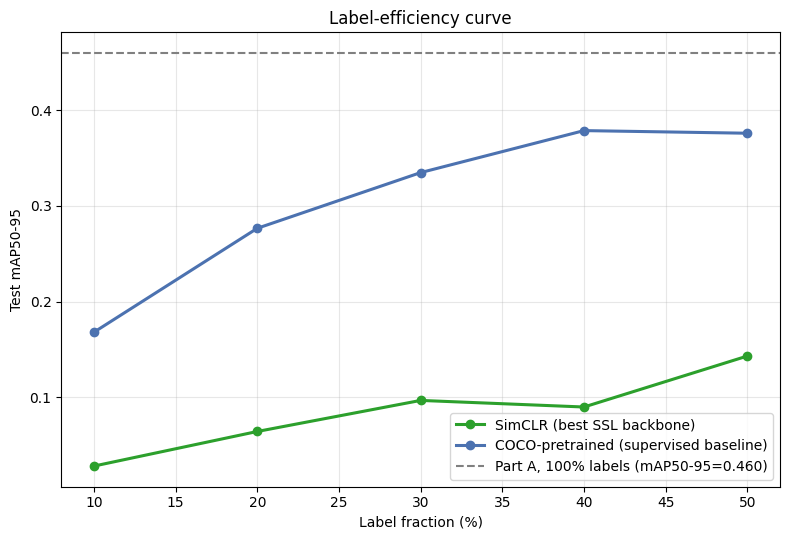

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for init_name, color in [("simclr", "#2ca02c"), ("coco", "#4c72b0")]:
    ys = [grid_results[(f, init_name)]["metrics/mAP50-95(B)"] for f in LABEL_FRACTIONS]
    ax.plot([f * 100 for f in LABEL_FRACTIONS], ys, marker="o", linewidth=2.2, color=color,
            label="SimCLR (best SSL backbone)" if init_name == "simclr" else "COCO-pretrained (supervised baseline)")

ax.axhline(PART_A_MAP5095, linestyle="--", color="gray", linewidth=1.5,
           label=f"Part A, 100% labels (mAP50-95={PART_A_MAP5095:.3f})")

ax.set_xlabel("Label fraction (%)")
ax.set_ylabel("Test mAP50-95")
ax.set_title("Label-efficiency curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_label_efficiency_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Break-even analysis

In [16]:
coco_50 = grid_results[(0.50, "coco")]["metrics/mAP50-95(B)"]
part_a_95pct = 0.95 * PART_A_MAP5095

simclr_curve = {f: grid_results[(f, "simclr")]["metrics/mAP50-95(B)"] for f in LABEL_FRACTIONS}

breakeven_vs_coco50 = next((f for f in LABEL_FRACTIONS if simclr_curve[f] >= coco_50), None)
breakeven_vs_parta95 = next((f for f in LABEL_FRACTIONS if simclr_curve[f] >= part_a_95pct), None)

print(f"COCO-pretrained @ 50% labels: mAP50-95 = {coco_50:.4f}")
print(f"95% of Part A reference:      mAP50-95 = {part_a_95pct:.4f}")
print()
print(f"Smallest rho where SimCLR-init matches/exceeds COCO@50%:      "
      f"{breakeven_vs_coco50 if breakeven_vs_coco50 else 'not reached within 10-50% grid'}")
print(f"Smallest rho where SimCLR-init reaches 95% of Part A (100%):  "
      f"{breakeven_vs_parta95 if breakeven_vs_parta95 else 'not reached within 10-50% grid'}")


COCO-pretrained @ 50% labels: mAP50-95 = 0.3761
95% of Part A reference:      mAP50-95 = 0.4370

Smallest rho where SimCLR-init matches/exceeds COCO@50%:      not reached within 10-50% grid
Smallest rho where SimCLR-init reaches 95% of Part A (100%):  not reached within 10-50% grid


### 5.4 Qualitative panel — SimCLR predictions at rho=0.1 vs rho=0.5

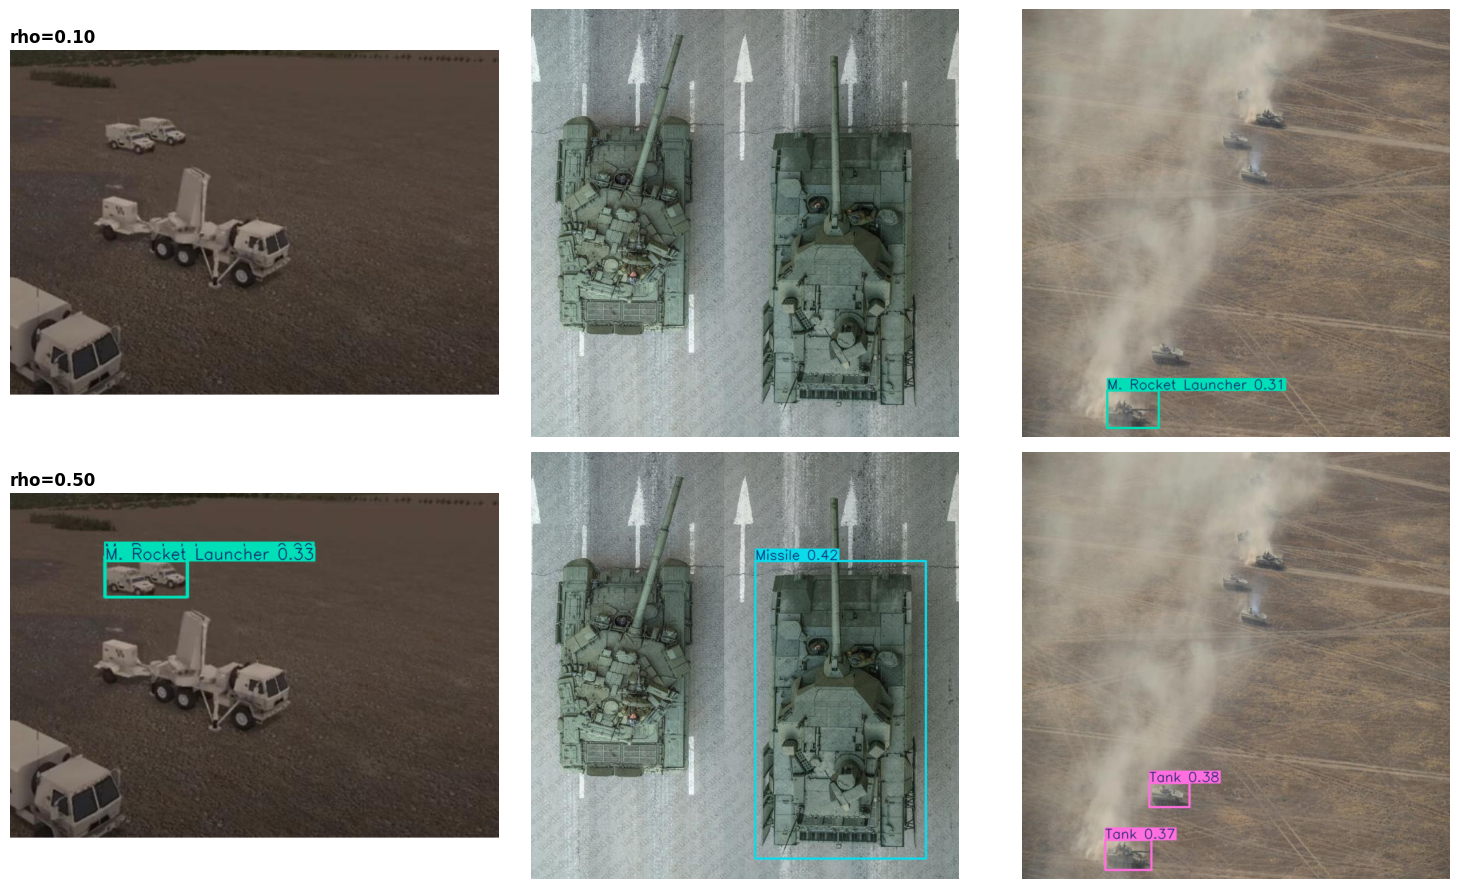

In [17]:
test_images_dir = RESPLIT_ROOT / "test" / "images"
sample_test_images = sorted(test_images_dir.glob("*"))[:3]

ckpt_01 = grid_results[(0.10, "simclr")].get("checkpoint")
ckpt_05 = grid_results[(0.50, "simclr")].get("checkpoint")

if ckpt_01 and ckpt_05:
    model_01 = YOLO(ckpt_01)
    model_05 = YOLO(ckpt_05)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for col, img_path in enumerate(sample_test_images):
        r01 = model_01.predict(str(img_path), conf=0.25, verbose=False)[0]
        r05 = model_05.predict(str(img_path), conf=0.25, verbose=False)[0]
        axes[0, col].imshow(r01.plot()[:, :, ::-1]); axes[0, col].axis("off")
        axes[1, col].imshow(r05.plot()[:, :, ::-1]); axes[1, col].axis("off")
    axes[0, 0].set_title("rho=0.10", loc="left", fontsize=12, fontweight="bold")
    axes[1, 0].set_title("rho=0.50", loc="left", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_qualitative_panel.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Checkpoints for rho=0.10 or rho=0.50 not found in grid_results -- check the training cell above.")


### 5.5 Export the best checkpoint across the grid

In [18]:
new_runs = {k: v for k, v in grid_results.items() if not v.get("reused_from_task1")}
best_key = max(new_runs, key=lambda k: new_runs[k]["metrics/mAP50-95(B)"])
best_frac, best_init = best_key
best_map5095 = new_runs[best_key]["metrics/mAP50-95(B)"]
best_checkpoint = new_runs[best_key]["checkpoint"]

print(f"Best grid cell: D{best_frac:.1f} / {best_init}  (test mAP50-95 = {best_map5095:.4f})")
print(f"Checkpoint: {best_checkpoint}")

task1_winner_map5095 = reused_simclr_20["metrics/mAP50-95(B)"]
if best_map5095 > task1_winner_map5095:
    print(f"\nThis BEATS the Task 1 winner (SimCLR@20% = {task1_winner_map5095:.4f}).")
    print("Publish this checkpoint as a Kaggle dataset and consider rerunning Notebook 5 (tracking) with it.")
else:
    print(f"\nDoes not beat the Task 1 winner (SimCLR@20% = {task1_winner_map5095:.4f}); "
          "Task 1's checkpoint remains the one used for tracking.")


Best grid cell: D0.4 / coco  (test mAP50-95 = 0.3788)
Checkpoint: /kaggle/working/bonus_outputs/yolo26_coco_40pct/finetune/weights/best.pt

This BEATS the Task 1 winner (SimCLR@20% = 0.0642).
Publish this checkpoint as a Kaggle dataset and consider rerunning Notebook 5 (tracking) with it.


## Final — Save run manifest (report traceability)

In [19]:
manifest = {
    "notebook": "partB-bonus-label-efficiency",
    "epochs_per_run": EPOCHS_BONUS,
    "label_fractions": LABEL_FRACTIONS,
    "subset_sizes": {f"{f:.2f}": len(SUBSETS[f]) for f in LABEL_FRACTIONS},
    "grid_results": {f"{f:.2f}_{i}": grid_results[(f, i)] for f in LABEL_FRACTIONS for i in INITS},
    "breakeven_vs_coco50": breakeven_vs_coco50,
    "breakeven_vs_parta95": breakeven_vs_parta95,
    "best_grid_cell": {"fraction": best_frac, "init": best_init, "mAP50_95": best_map5095,
                        "checkpoint": best_checkpoint},
    "seed": SEED,
}
manifest_path = OUTPUT_DIR / "bonus_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
print("Saved:", manifest_path)


Saved: /kaggle/working/bonus_outputs/bonus_manifest.json
